In [43]:
import os
import pandas as pd
import numpy as np

trainPath='/kaggle/input/competitions/spaceship-titanic/train.csv'
testPath='/kaggle/input/competitions/spaceship-titanic/test.csv'
sampleSubmission='/kaggle/input/competitions/spaceship-titanic/sample_submission.csv'

train=pd.read_csv(trainPath, header=0)
test=pd.read_csv(testPath, header=0)
submission=pd.read_csv(sampleSubmission, header=0)

target=train[['Transported']]

In [44]:
# Split group and cabin
def splitGroupAndCabin(train):
    train['Group']=train['PassengerId'].str.split('_').str[0]
    train['Number']=train['PassengerId'].str.split('_').str[1]
    
    train['Deck']=train['Cabin'].str.split('/').str[0]
    train['Num']=train['Cabin'].str.split('/').str[1]
    train['Side']=train['Cabin'].str.split('/').str[2]
    return train


# Impute Homeplanet and Destination
def imputeHomePlanetAndDestination(train):
    x=train.groupby('Group')['HomePlanet']\
    .value_counts(dropna=False)\
    .groupby(level=0)\
    .rank(ascending=False, method='min')\
    .reset_index(name='rank')
    
    x=x[x['rank']==1]
    defaultHome=dict(zip(x['Group'], x['HomePlanet']))
    
    y=train.groupby('Group')['Destination']\
    .value_counts(dropna=False)\
    .groupby(level=0)\
    .rank(ascending=False, method='min')\
    .reset_index(name='rank')
    
    y=y[y['rank']==1]
    defaultDest=dict(zip(y['Group'], y['Destination']))
    
    train['HomePlanet']=train['HomePlanet'].fillna(train['Group'].map(defaultHome))
    train['Destination']=train['Destination'].fillna(train['Group'].map(defaultDest))

    x=train.groupby('Deck')['HomePlanet']\
        .value_counts(dropna=False)\
        .groupby(level=0)\
        .rank(ascending=False, method='min')\
        .reset_index(name='rank')
    
    x=x[x['rank']==1]
    defaultHome=dict(zip(x['Deck'], x['HomePlanet']))
    
    y=train.groupby('Deck')['Destination']\
        .value_counts(dropna=False)\
        .groupby(level=0)\
        .rank(ascending=False, method='min')\
        .reset_index(name='rank')
    
    y=y[y['rank']==1]
    defaultDest=dict(zip(y['Deck'], y['Destination']))
    
    train['HomePlanet']=train['HomePlanet'].fillna(train['Deck'].map(defaultHome))
    train['Destination']=train['Destination'].fillna(train['Deck'].map(defaultDest))
    return train

# create journey column
def createJourney(train):
    train['Journey']=train['HomePlanet']+'_'+train['Destination']
    return train

# create Deck column imputations
def imputeDeckSide(train):
    # DECK
    y=(train.groupby(['Journey'])['Deck']\
    .value_counts(dropna=False)\
    .groupby(level=0)\
    .rank(ascending=False, method='min')\
    .reset_index(name='rank'))
    
    y=y[y['rank']==1]
    defaultDeck=dict(zip(y['Journey'], y['Deck']))
    
    train['Deck']=train['Deck'].fillna(train['Journey'].map(defaultDeck))
    
    # NUM
    train['Num']=train['Num'].fillna('0')
    
    # SIDE
    y=(train.groupby(['Journey'])['Side']\
    .value_counts(dropna=False)\
    .groupby(level=0)\
    .rank(ascending=False, method='min')\
    .reset_index(name='rank'))
    
    y=y[y['rank']==1]
    defaultDeck=dict(zip(y['Journey'], y['Side']))
    
    train['Side']=train['Side'].fillna(train['Journey'].map(defaultDeck))

    train['Cabin']=train['Cabin'].fillna(train['Deck']+'/'+train['Num']+'/'+train['Side'])

    train['FirstName'], train['LastName']=train['Name'].str.split(' ').str[0], train['Name'].str.split(' ').str[1]
    return train

# Fill cryosleep
def imputeCryoSleep(train):
    # passengers with same group number and journey path will have same cryosleep state

    y=(train.groupby(['Group', 'Journey', 'LastName'])['CryoSleep']\
    .value_counts(dropna=False)\
    .groupby(level=0)\
    .rank(ascending=False, method='min')\
    .reset_index(name='rank'))
    
    y=y[y['rank']==1]
    
    defaultDeck=dict(zip(y['Group']+'_'+y['Journey']+'_'+y['LastName'], y['CryoSleep']))
    train['ABC']=train['Group']+'_'+train['Journey']+'_'+train['LastName']
    train['CryoSleep']=train['CryoSleep'].fillna(train['ABC'].map(defaultDeck))
    return train

# impute Age
def imputeAge(train):
    train['Age']=train['Age'].fillna(train['Age'].median())
    return train

# create LuxurySpend column
def createLuxury(train):
    columns=['RoomService', 'FoodCourt', 'Spa', 'ShoppingMall', 'VRDeck']
    for i in columns:
        train[i]=train[i].fillna(0)
    train['Luxuries']=train['RoomService']+train['FoodCourt']+train['Spa']+\
                    train['ShoppingMall']+train['VRDeck']
    train['Luxuries']=np.log1p(train['Luxuries'])
    return train

# encode categorical data
def encodings(df):
    df=df[['HomePlanet', 'Destination', 'Journey', 'CryoSleep', 'Age', 'Luxuries', 'Deck', 'Side']]
    df=pd.get_dummies(df, columns=['HomePlanet', 'Destination', 'Journey', 'Deck'], drop_first=True)
    df['CryoSleep']=df['CryoSleep'].fillna(False).astype(int)
    
    sideMap={'P': 0, 'S': 1}
    df['Side']=df['Side'].map(sideMap).fillna(0)
    df['Luxuries']=np.log1p(df['Luxuries'])
    return df


In [48]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

def modelTrain(df, target):
    df_train, df_test, target_train, target_test = train_test_split(df, target, \
                                            test_size=0.2,
                                            stratify=target)

    model=XGBClassifier(n_estimators=15, eval_metric='logloss', tree_method='hist', device='cuda')
    model.fit(df_train, target_train)
    return model

def testModel(df_test, model):
    target_pred=model.predict(df_test)
    target_prob = model.predict_proba(df_test)[:, 1]

    return target_pred

    # accuracy = accuracy_score(target_test, target_pred)
    # roc_auc = roc_auc_score(target_test, target_prob)
    
    # print(f"Validation Accuracy: {accuracy:.4f}")
    # print(f"Validation ROC-AUC:  {roc_auc:.4f}")
    # return accuracy, roc_auc

In [49]:
def transform(df):
    df=splitGroupAndCabin(df)
    df=imputeHomePlanetAndDestination(df)
    df=createJourney(df)
    df=imputeDeckSide(df)
    df=imputeCryoSleep(df)
    df=imputeAge(df)
    df=createLuxury(df)
    df=encodings(df)

    return df

In [50]:
feature=transform(train)
testing=transform(test)

model=modelTrain(feature, target)
targetTest=testModel(testing, model)

targetTest

array([1, 0, 1, ..., 1, 0, 1])

In [38]:
targetTest['']

2

In [53]:
answer=pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Transported': targetTest.astype('bool')
})

#answer.to_csv('/submission.csv', index=False)

In [63]:
answer.drop(columns=['Unnamed: 0'], errors='ignore')
answer.to_csv('/kaggle/working/submission.csv', index=False)

In [64]:
a=pd.read_csv('/kaggle/working/submission.csv')
a['Transported'].unique()

array([ True, False])

In [182]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

def modelTrain(df, target):
    df_train, df_test, target_train, target_test = train_test_split(df, target, \
                                            test_size=0.2,
                                            stratify=target)

    model=XGBClassifier(n_estimators=15, eval_metric='logloss', tree_method='hist', device='cuda')
    model.fit(df_train, target_train)
    return model

def testModel(df_test, model):
    target_pred=model.predict(df_test)
    target_prob = model.predict_proba(df_test)[:, 1]

    accuracy = accuracy_score(target_test, target_pred)
    roc_auc = roc_auc_score(target_test, target_prob)
    
    print(f"Validation Accuracy: {accuracy:.4f}")
    print(f"Validation ROC-AUC:  {roc_auc:.4f}")
    return accuracy, roc_auc

In [ ]:
model=modelTrain()

In [176]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   CryoSleep                     4277 non-null   int64  
 1   Age                           4277 non-null   float64
 2   Luxuries                      4277 non-null   float64
 3   Side                          4277 non-null   float64
 4   HomePlanet_Europa             4277 non-null   bool   
 5   HomePlanet_Mars               4277 non-null   bool   
 6   Destination_PSO J318.5-22     4277 non-null   bool   
 7   Destination_TRAPPIST-1e       4277 non-null   bool   
 8   Journey_Earth_PSO J318.5-22   4277 non-null   bool   
 9   Journey_Earth_TRAPPIST-1e     4277 non-null   bool   
 10  Journey_Europa_55 Cancri e    4277 non-null   bool   
 11  Journey_Europa_PSO J318.5-22  4277 non-null   bool   
 12  Journey_Europa_TRAPPIST-1e    4277 non-null   bool   
 13  Jou

# **FINDING RELATIONS**

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

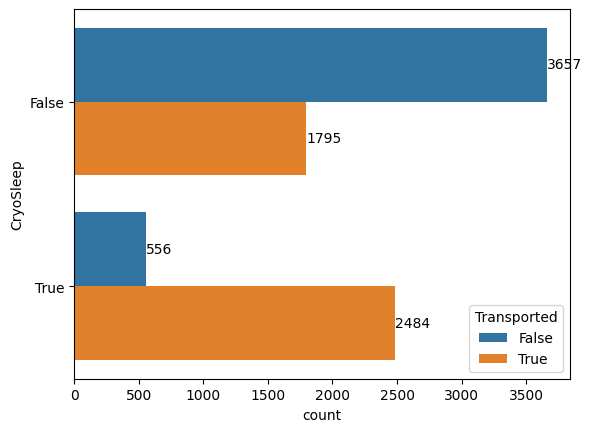

In [37]:
ax=sns.countplot(train, y=train['CryoSleep'], hue='Transported')
for container in ax.containers:
    ax.bar_label(container)

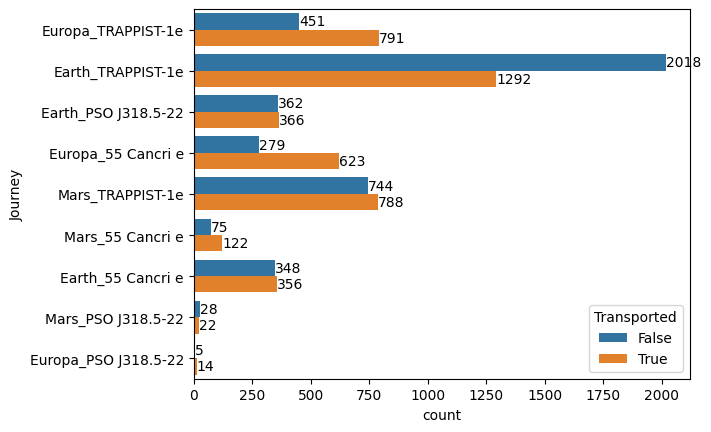

In [38]:
ax=sns.countplot(train, y=train['Journey'], hue='Transported')
for container in ax.containers:
    ax.bar_label(container)

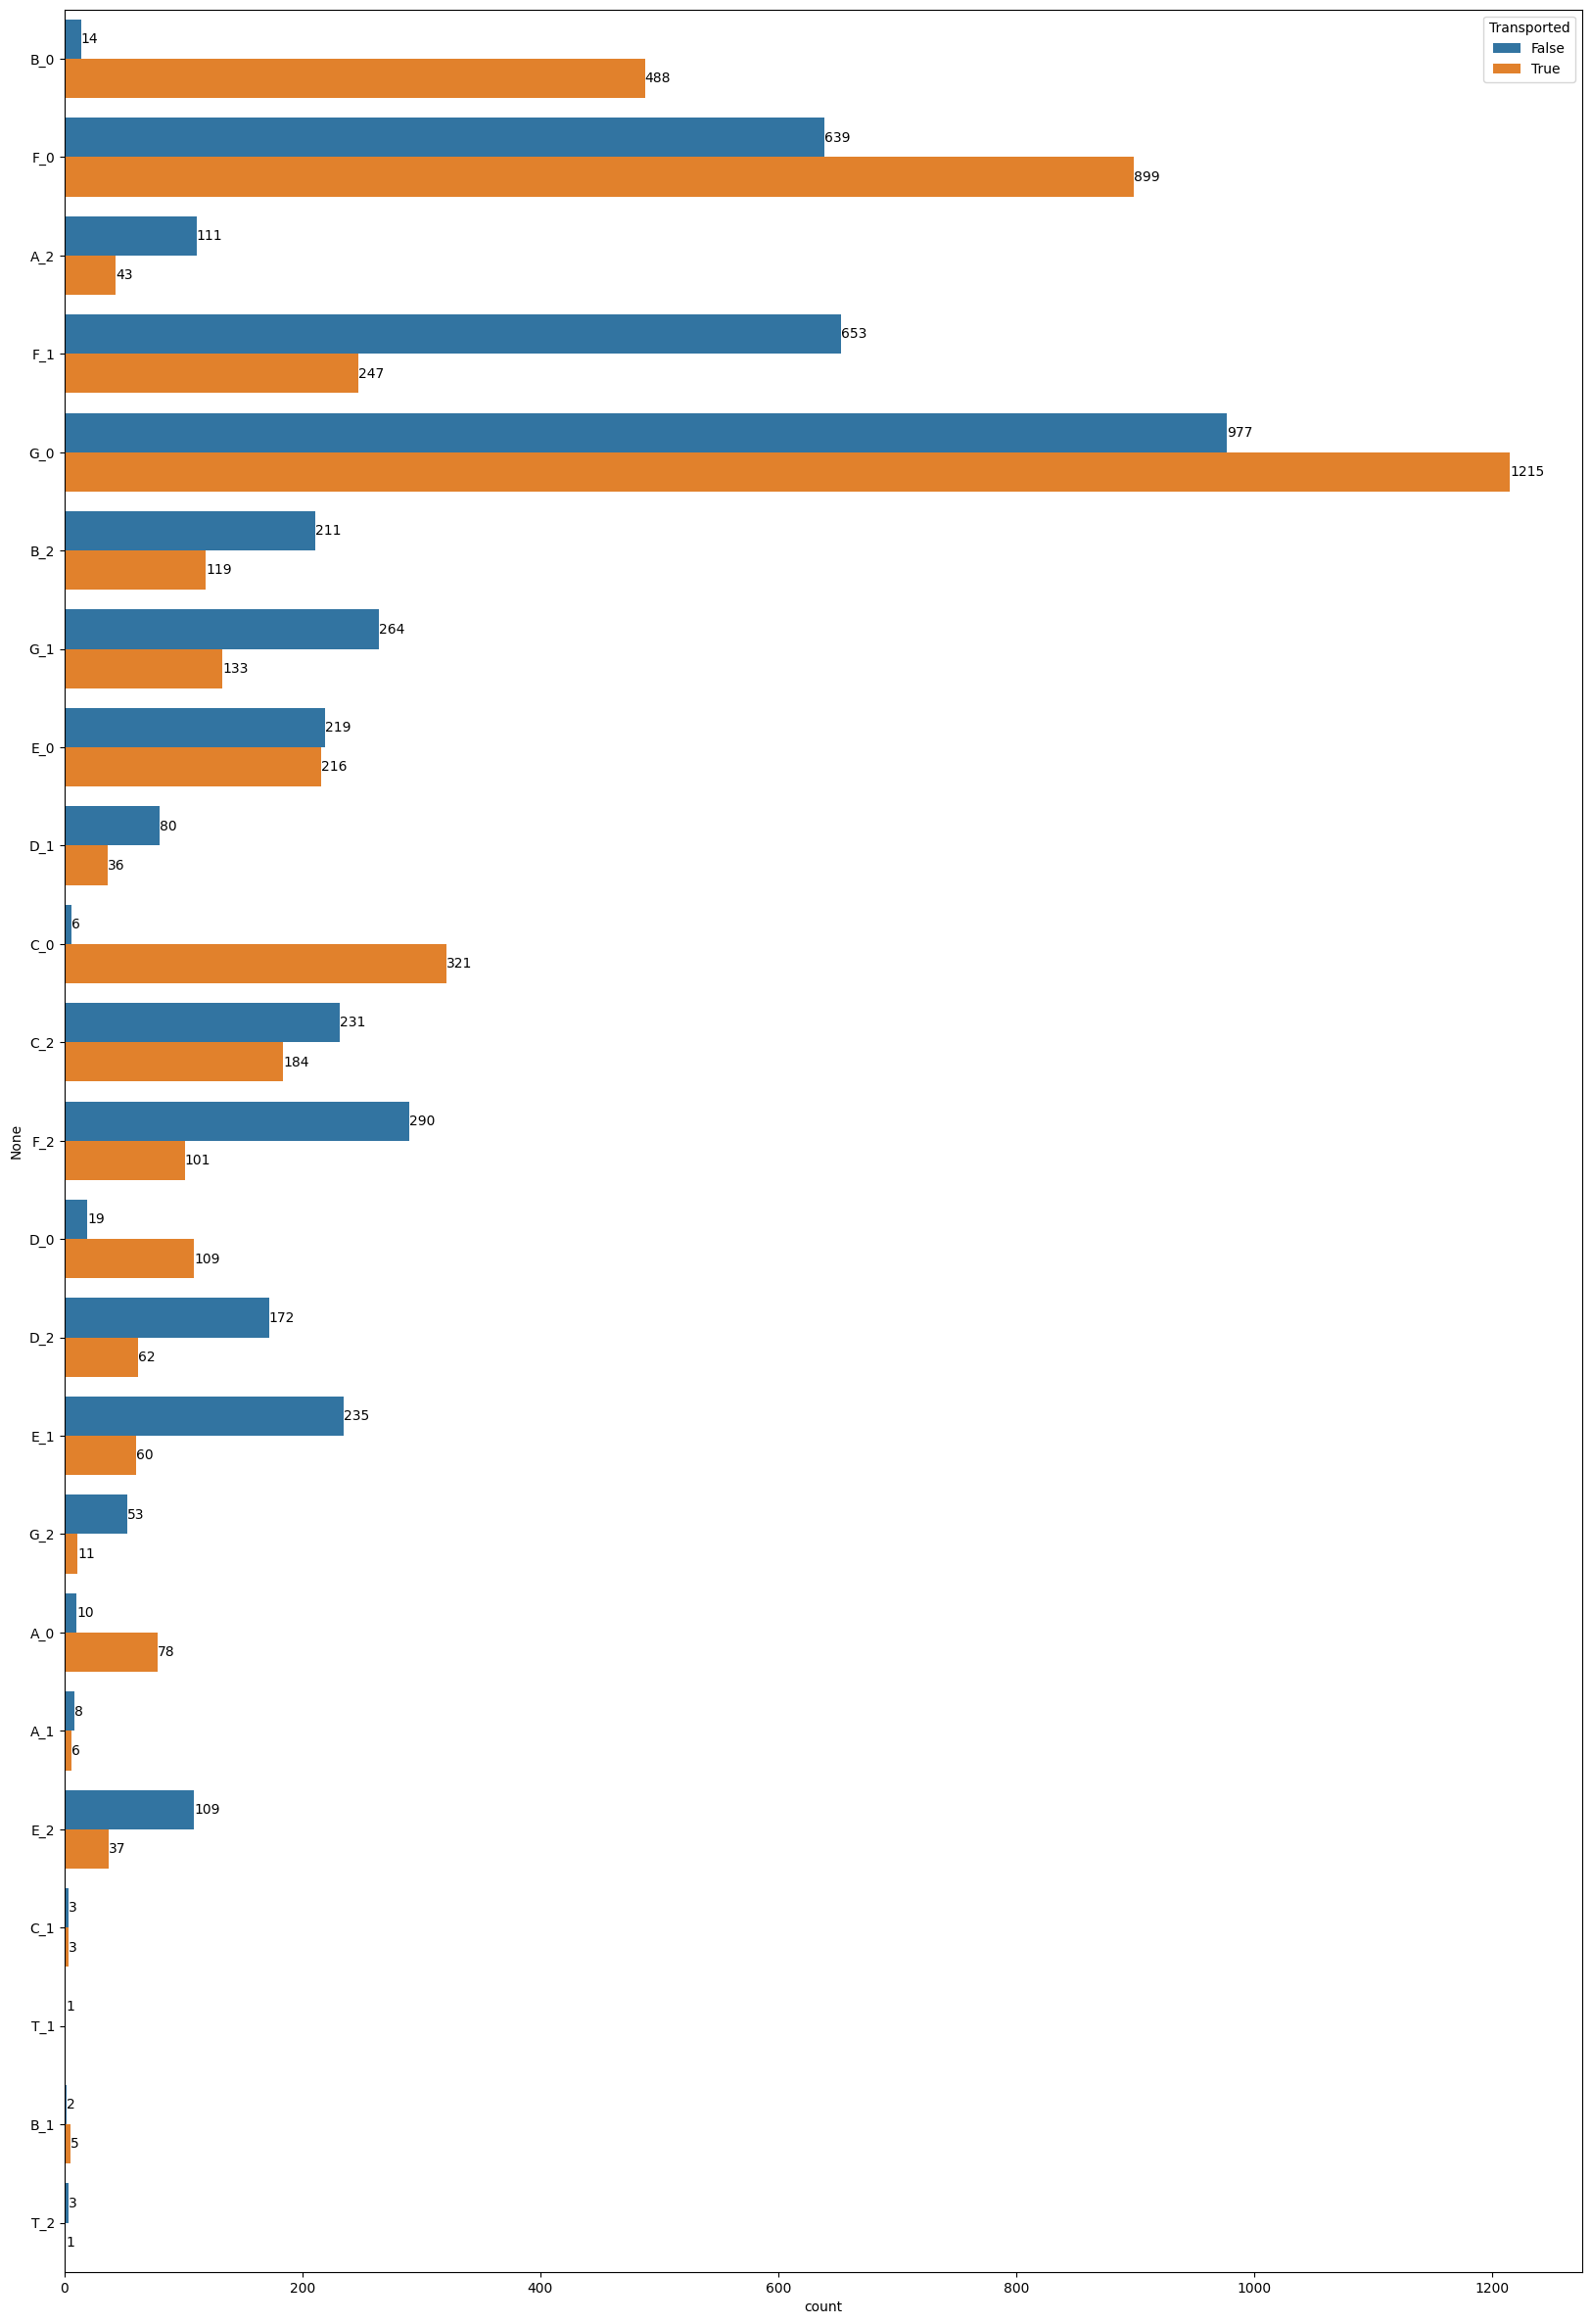

In [39]:
plt.figure(figsize=(20, 30))
ax=sns.countplot(train, y=train['Deck']+'_'+(train['LuxuryBucket'].astype(str)), hue='Transported')
for container in ax.containers:
    ax.bar_label(container)

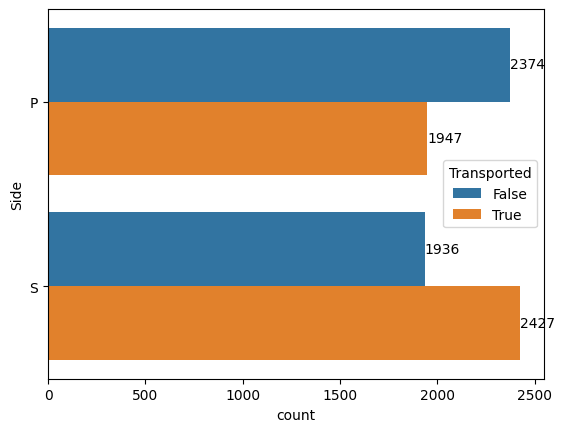

In [45]:
plt.figure()
ax=sns.countplot(train, y=train['Side'], hue='Transported')
for container in ax.containers:
    ax.bar_label(container)

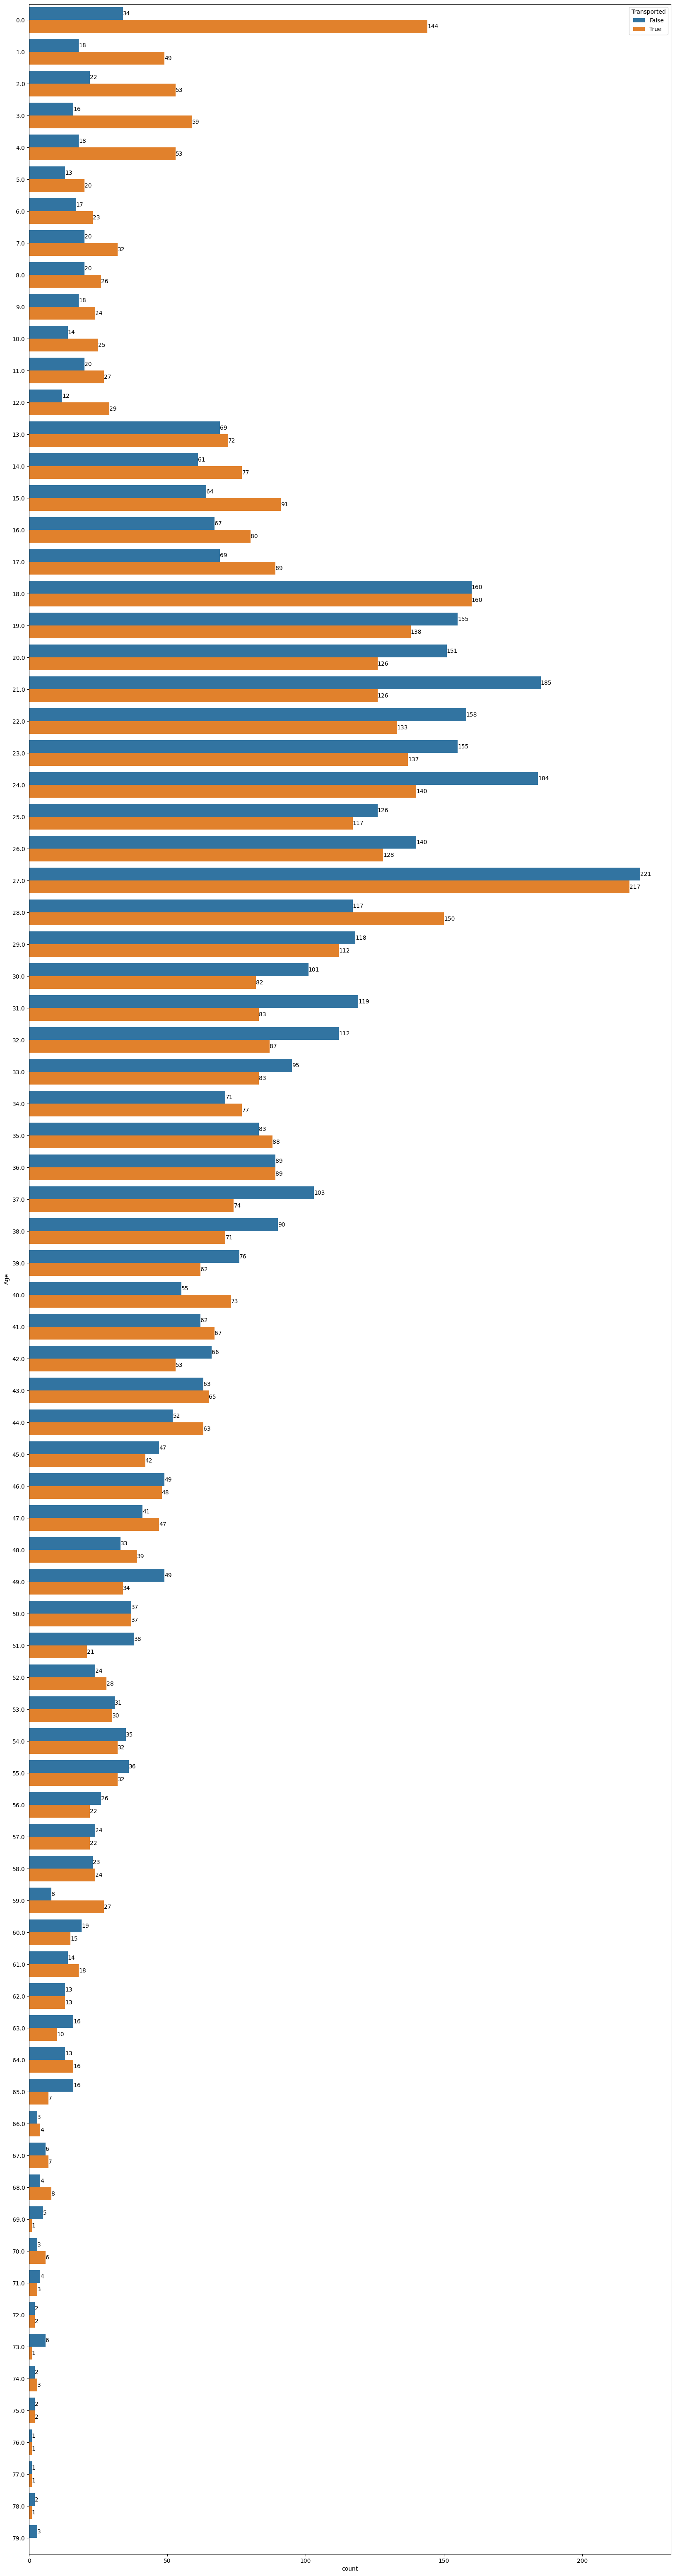

In [40]:
plt.figure(figsize=(20, 80))
ax=sns.countplot(train, y=train['Age'], hue='Transported')
for container in ax.containers:
    ax.bar_label(container)

# **Model Selection and Run**

In [177]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

def modelTrain(df, target):
    df_train, df_test, target_train, target_test = train_test_split(df, target, \
                                            test_size=0.2,
                                            stratify=target)

    model=XGBClassifier(n_estimators=15, eval_metric='logloss', tree_method='hist', device='cuda')
    model.fit(df_train, target_train)
    return model

def testModel(df_test):
    target_pred=model.predict(df_test)
    target_prob = model.predict_proba(df_test)[:, 1]

    accuracy = accuracy_score(target_test, target_pred)
    roc_auc = roc_auc_score(target_test, target_prob)
    
    print(f"Validation Accuracy: {accuracy:.4f}")
    print(f"Validation ROC-AUC:  {roc_auc:.4f}")
    return accuracy, roc_auc

    
print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation ROC-AUC:  {roc_auc:.4f}")

Validation Accuracy: 0.7642
Validation ROC-AUC:  0.8166


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:13:03] WARNING: /__w/xgboost/xgboost/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:13:03] WARNING: /__w/xgboost/xgboost/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


In [169]:
t

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4272,9266_02,Earth,True,G/1496/S,TRAPPIST-1e,34.0,False,0.0,0.0,0.0,0.0,0.0,Jeron Peter
4273,9269_01,Earth,False,NaN,TRAPPIST-1e,42.0,False,0.0,847.0,17.0,10.0,144.0,Matty Scheron
4274,9271_01,Mars,True,D/296/P,55 Cancri e,NaN,False,0.0,0.0,0.0,0.0,0.0,Jayrin Pore
4275,9273_01,Europa,False,D/297/P,NaN,NaN,False,0.0,2680.0,0.0,0.0,523.0,Kitakan Conale


In [ ]:
pred=model.predict(test)
prob = model.predict_proba(test)[:, 1]

accuracy = accuracy_score(test, pred)
roc_auc = roc_auc_score(test, prob)